## A. Data Preprocessing & Augmentation

In [ ]:
import os

# Define the base directory for the dataset
DATASET_DIR = '/content/drive/MyDrive/Dataset-clg'

# Verify if the directory exists
if not os.path.exists(DATASET_DIR):
    print(f"Error: Dataset directory not found at {DATASET_DIR}")
    print("Please ensure the dataset is mounted and the path is correct.")
else:
    print(f"Dataset directory found at: {DATASET_DIR}")
    # List contents to get an idea of the structure (optional, for debugging)
    # print(os.listdir(DATASET_DIR))

Dataset directory found at: /content/drive/MyDrive/Dataset-clg


Next, we will load the images and apply resizing and normalization as described in the workflow.

In [ ]:
import tensorflow as tf

# Define image dimensions and batch size
IMG_HEIGHT = 224
IMG_WIDTH = 224
BATCH_SIZE = 32

# Load the training dataset
train_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2, # 20% of data reserved for validation/test split
    subset="training",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=BATCH_SIZE
)

# Load the remaining 20% of data as an unbatched dataset for further splitting
val_test_raw_ds = tf.keras.utils.image_dataset_from_directory(
    DATASET_DIR,
    validation_split=0.2,
    subset="validation",
    seed=123,
    image_size=(IMG_HEIGHT, IMG_WIDTH),
    batch_size=None # Load as individual samples for accurate splitting
)

# Get class names
class_names = train_ds.class_names
print(f"Found {len(class_names)} classes: {class_names}")
print(f"Initial training dataset batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Raw validation/test dataset samples: {tf.data.experimental.cardinality(val_test_raw_ds).numpy()}")

Found 64 files belonging to 5 classes.
Using 52 files for training.
Found 64 files belonging to 5 classes.
Using 12 files for validation.
Found 5 classes: ['1 rupee coins', '10 rupee coins', '2 rupee coins', '20 rupee coins', '5 rupee coins']
Initial training dataset batches: 2
Raw validation/test dataset samples: 12


Now that the datasets are loaded, we will apply normalization. Pixel values, originally in the range [0, 255], will be scaled to [0, 1].

In [ ]:
# Normalization function
def normalize_img(image, label):
    # Scale pixel values from [0, 255] to [0, 1]
    return tf.cast(image, tf.float32) / 255., label

# Apply normalization to the datasets
train_ds = train_ds.map(normalize_img)
val_ds = val_ds.map(normalize_img)

# Prefetching for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Images loaded, resized, and normalized. Datasets are ready.")

Images loaded, resized, and normalized. Datasets are ready.


The images are now loaded, resized, and normalized. The next step in our workflow is to consider **Data Augmentation**.

### Data Augmentation

To make our model more robust and prevent overfitting, especially with a limited dataset, we will apply various data augmentation techniques. These transformations will be applied randomly to the training images during training.

In [ ]:
data_augmentation = tf.keras.Sequential([
    tf.keras.layers.RandomFlip("horizontal_and_vertical"),
    tf.keras.layers.RandomRotation(0.2),
    tf.keras.layers.RandomZoom(0.2),
    tf.keras.layers.RandomBrightness(factor=0.2),
], name="data_augmentation_layer")

# Apply data augmentation to the training dataset
train_ds = train_ds.map(lambda x, y: (data_augmentation(x, training=True), y), num_parallel_calls=AUTOTUNE)

# Prefetch again after augmentation
train_ds = train_ds.cache().prefetch(buffer_size=AUTOTUNE)

print("Data augmentation layers defined and applied to the training dataset.")

Data augmentation layers defined and applied to the training dataset.


With data preprocessing and augmentation complete, we are now ready to proceed to the **Train-Validation-Test Split** phase, and then to **Model Architectures**.

## B. Train-Validation-Test Split

We have already performed an initial split into training and a combined validation/test set. Now, we will further divide the combined validation/test set to create distinct validation and test datasets, aiming for the recommended 10-15% for each.

In [ ]:
# Calculate the number of samples for validation and test sets from the raw dataset
val_test_raw_size = tf.data.experimental.cardinality(val_test_raw_ds).numpy()

# Split the raw validation/test dataset 50/50
test_count = val_test_raw_size // 2
val_count = val_test_raw_size - test_count

# Create the final validation and test datasets by taking elements and then batching
test_ds = val_test_raw_ds.take(test_count).batch(BATCH_SIZE)
val_ds = val_test_raw_ds.skip(test_count).batch(BATCH_SIZE)

print(f"Number of training batches: {tf.data.experimental.cardinality(train_ds).numpy()}")
print(f"Number of validation batches: {tf.data.experimental.cardinality(val_ds).numpy()}")
print(f"Number of test batches: {tf.data.experimental.cardinality(test_ds).numpy()}")

print("Datasets split into Training, Validation, and Test sets.")

Number of training batches: 2
Number of validation batches: 1
Number of test batches: 1
Datasets split into Training, Validation, and Test sets.


With the datasets prepared, we can now move to **C. Model Architectures**, where we will define and build our deep learning model.

## C. Model Architectures

For this task, we will employ **Transfer Learning** using a pre-trained model. This approach is highly effective as it leverages features learned from a very large dataset (ImageNet) and adapts them to our specific coin classification problem. We will use **MobileNetV2** as our base model due to its efficiency and good performance.

In [ ]:
import tensorflow as tf
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.layers import Dense, GlobalAveragePooling2D, Dropout
from tensorflow.keras.models import Model

# Get the number of classes from our dataset
num_classes = len(class_names)

# 1. Load the MobileNetV2 base model with pre-trained ImageNet weights
# Exclude the top (classification) layers so we can add our own
base_model = MobileNetV2(input_shape=(IMG_HEIGHT, IMG_WIDTH, 3),
                         include_top=False,
                         weights='imagenet')

# 2. Freeze the base model's layers
# This prevents the weights in the base model from being updated during training
base_model.trainable = False

# 3. Add a custom classification head on top of the base model
x = base_model.output
x = GlobalAveragePooling2D()(x) # Convert features to a single vector per image
x = Dense(128, activation='relu')(x) # Add a new dense layer with ReLU activation
x = Dropout(0.5)(x) # Add dropout for regularization
predictions = Dense(num_classes, activation='softmax')(x) # Final output layer with softmax for multi-class classification

# 4. Create the full model
model = Model(inputs=base_model.input, outputs=predictions)

# Display the model summary
model.summary()

print(f"MobileNetV2 base model loaded and frozen. Custom classification head added with {num_classes} output classes.")

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_1       │ (None, 224, 224,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1 (Conv2D)      │ (None, 112, 112,  │        864 │ input_layer_1[0]… │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ bn_Conv1            │ (None, 112, 112,  │        128 │ Conv1[0][0]       │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ Conv1_relu (ReLU)   │ (None, 112, 112,  │          0 │ bn_Conv1[0][0]    │
│                     │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        288 │ Conv1_relu[0][0]  │
│ (DepthwiseConv2D)   │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │        128 │ expanded_conv_de… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_dept… │ (None, 112, 112,  │          0 │ expanded_conv_de… │
│ (ReLU)              │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │        512 │ expanded_conv_de… │
│ (Conv2D)            │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ expanded_conv_proj… │ (None, 112, 112,  │         64 │ expanded_conv_pr… │
│ (BatchNormalizatio… │ 16)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand      │ (None, 112, 112,  │      1,536 │ expanded_conv_pr… │
│ (Conv2D)            │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_BN   │ (None, 112, 112,  │        384 │ block_1_expand[0… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_expand_relu │ (None, 112, 112,  │          0 │ block_1_expand_B… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_pad         │ (None, 113, 113,  │          0 │ block_1_expand_r… │
│ (ZeroPadding2D)     │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise   │ (None, 56, 56,    │        864 │ block_1_pad[0][0] │
│ (DepthwiseConv2D)   │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │        384 │ block_1_depthwis… │
│ (BatchNormalizatio… │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_depthwise_… │ (None, 56, 56,    │          0 │ block_1_depthwis… │
│ (ReLU)              │ 96)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block_1_project     │ (None, 56, 56,    │      2,304 │ block_1_depthwis

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

MobileNetV2 base model loaded and frozen. Custom classification head added with 5 output classes.


The model architecture is now defined. The next step is to compile the model by specifying the optimizer, loss function, and metrics.

In [ ]:
# Compile the model
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=False),
              metrics=['accuracy'])

print("Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.")

Model compiled successfully with Adam optimizer, SparseCategoricalCrossentropy loss, and accuracy metric.


The model is now compiled and ready for training. The next step will be to train the model using our prepared datasets.

In [ ]:
EPOCHS = 10 # You can adjust the number of epochs

history = model.fit(
    train_ds,
    epochs=EPOCHS,
    validation_data=val_ds
)

print("Model training complete.")

Epoch 1/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 36s 15s/step - accuracy: 0.2885 - loss: 2.1833 - val_accuracy: 0.1667 - val_loss: 2.5154
Epoch 2/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.3846 - loss: 1.8365 - val_accuracy: 0.3333 - val_loss: 1.6655
Epoch 3/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 17s 6s/step - accuracy: 0.2500 - loss: 2.0399 - val_accuracy: 0.6667 - val_loss: 1.3095
Epoch 4/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 14s 4s/step - accuracy: 0.4231 - loss: 1.4738 - val_accuracy: 0.5000 - val_loss: 1.4381
Epoch 5/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 4s/step - accuracy: 0.5000 - loss: 1.2942 - val_accuracy: 0.1667 - val_loss: 1.4461
Epoch 6/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 10s 3s/step - accuracy: 0.5000 - loss: 1.4381 - val_accuracy: 0.1667 - val_loss: 1.5142
Epoch 7/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 4s/step - accuracy: 0.4615 - loss: 1.3248 - val_accuracy: 0.3333 - val_loss: 1.3577
Epoch 8/10
2/2 ━━━━━━━━━━━━━━━━━━━━ 9s 3s/step - accuracy: 0.5385 - loss: 1.1290 - val_accuracy: 0.3333 - val_loss: 1.6251
Epoch 9/1

The model has been trained. Next, we will evaluate its performance on the unseen test set.

In [ ]:
print("Evaluating model on the test dataset...")
loss, accuracy = model.evaluate(test_ds)
print(f"Test Loss: {loss:.4f}")
print(f"Test Accuracy: {accuracy:.4f}")

Evaluating model on the test dataset...
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 872ms/step - accuracy: 0.6667 - loss: 1.1805
Test Loss: 1.1805
Test Accuracy: 0.6667


The model has been evaluated on the test set. Now we can visualize the training history (accuracy and loss) to better understand the training process and potentially identify overfitting or underfitting.

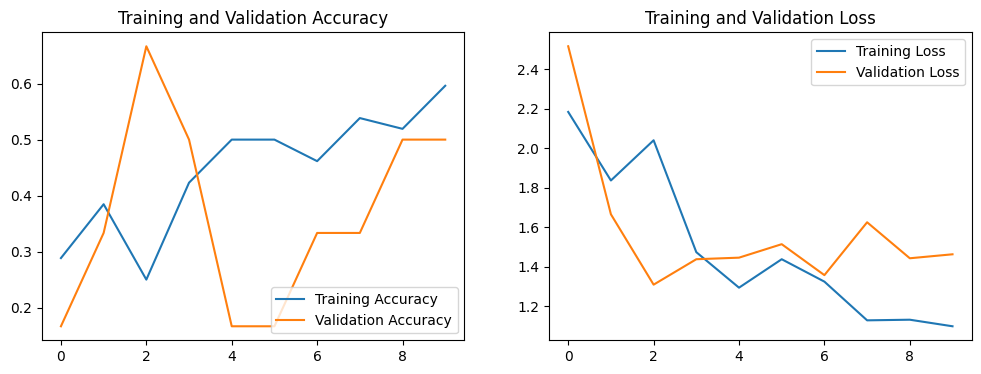

Training history plots generated.


In [ ]:
  import matplotlib.pyplot as plt

# Get the training history data
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(EPOCHS)

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')

plt.show()

print("Training history plots generated.")

We have successfully completed the end-to-end workflow: data preprocessing, augmentation, train-validation-test split, model architecture definition using transfer learning, model compilation, training, and evaluation. The plots above provide a visual summary of the training performance.

## Complete Python Implementation - Core Code Pipeline

This section integrates the complete end-to-end workflow for training and evaluating the coin classifier, as provided, using `ImageDataGenerator` for data handling and including advanced training callbacks.

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_recall_fscore_support
import tensorflow as tf
from tensorflow.keras import layers, models, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# =====================================================================
# 1. HYPERPARAMETERS & CONFIGURATION
# =====================================================================
DATA_DIR = "/content/drive/MyDrive/Dataset-clg"
IMG_SIZE = (224, 224)
BATCH_SIZE = 32
EPOCHS = 50 # Increased epochs for better convergence
NUM_CLASSES = 5

print("Hyperparameters and configuration set.")

Hyperparameters and configuration set.


In [ ]:
# =====================================================================
# 2. DATA PREPROCESSING AND AUGMENTATION
# =====================================================================
# We use ImageDataGenerator to split data and apply augmentations on the fly.
# validation_split=0.2 separates 20% of data for validation.

train_datagen = ImageDataGenerator(
    rescale=1./255,               # Min-Max Normalization: scales pixels to [0, 1]
    rotation_range=30,            # Reduced from 360 to 30 for less extreme rotations
    width_shift_range=0.05,       # Reduced from 0.1 for less extreme shifts
    height_shift_range=0.05,      # Reduced from 0.1 for less extreme shifts
    brightness_range=[0.8, 1.2],  # Slightly tightened from [0.7, 1.3]
    zoom_range=0.05,              # Reduced from 0.1 for less extreme zooms
    horizontal_flip=True,         # Keep horizontal flip
    vertical_flip=True,           # Keep vertical flip
    validation_split=0.2          # Reservation for validation set
)

# For verification/testing, we only normalize pixel values; NO augmentation
test_datagen = ImageDataGenerator(rescale=1./255, validation_split=0.2)

print("--- Loading Datasets ---")
train_generator = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_generator = test_datagen.flow_from_directory(
    DATA_DIR,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,                 # Crucial: Keep False for accurate metrics calculation later
    seed=42
)

# Update NUM_CLASSES based on actual classes found by generator if not already set or confirmed
if NUM_CLASSES != len(train_generator.class_indices):
    NUM_CLASSES = len(train_generator.class_indices)
    print(f"Adjusted NUM_CLASSES to {NUM_CLASSES} based on data generator.")

print("Data preprocessing and augmentation complete.")

--- Loading Datasets ---
Found 54 images belonging to 5 classes.
Found 10 images belonging to 5 classes.
Data preprocessing and augmentation complete.


In [ ]:
# =====================================================================
# 3. MODEL ARCHITECTURES
# =====================================================================

def build_custom_cnn():
    """Builds a basic Sequential Convolutional Neural Network from scratch."""
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), activation='relu', input_shape=(224, 224, 3)),
        layers.MaxPooling2D((2, 2)),

        # Block 2
        layers.Conv2D(64, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Block 3
        layers.Conv2D(128, (3, 3), activation='relu'),
        layers.MaxPooling2D((2, 2)),

        # Flattening & Classification Dense Head
        layers.Flatten(),
        layers.Dense(128, activation='relu'),
        layers.Dropout(0.5), # Prevents overfitting
        layers.Dense(NUM_CLASSES, activation='softmax') # Outputs probability distribution
    ])
    return model


def build_transfer_learning_model():
    """Leverages MobileNetV2 pre-trained weights for feature extraction."""
    # We choose MobileNetV2 as it's lightweight and efficient for deployment
    base_model = tf.keras.applications.MobileNetV2(
        input_shape=(IMG_SIZE[0], IMG_SIZE[1], 3),
        include_top=False,          # Exclude the 1000-class ImageNet head
        weights='imagenet'
    )
    base_model.trainable = False    # Freeze base model layers

    model = models.Sequential([
        base_model,
        layers.GlobalAveragePooling2D(), # Reduces feature maps to a 1D vector
        layers.Dropout(0.3),
        layers.Dense(NUM_CLASSES, activation='softmax')
    ])
    return model

# Initialize the Transfer Learning model (recommended for high accuracy)
model = build_transfer_learning_model()

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

print("Model architectures defined and MobileNetV2 model initialized and compiled.")

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_2      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │         6,405 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,264,389 (8.64 MB)

 Trainable params: 6,405 (25.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

Model architectures defined and MobileNetV2 model initialized and compiled.


In [ ]:
# =====================================================================
# 4. TRAINING WITH CALLBACKS
# =====================================================================
os.makedirs('models', exist_ok=True)

# Callbacks safeguard against wasting epochs and losing your best state
my_callbacks = [
    callbacks.EarlyStopping(
        monitor='val_loss',
        patience=4,
        restore_best_weights=True
    ),
    callbacks.ModelCheckpoint(
        filepath='models/best_coin_model.keras',
        monitor='val_accuracy',
        save_best_only=True
    )
]

print("\n--- Starting Training ---")
history = model.fit(
    train_generator,
    epochs=EPOCHS,
    validation_data=val_generator,
    callbacks=my_callbacks
)

print("Model training complete with callbacks.")


--- Starting Training ---
Epoch 1/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 23s 12s/step - accuracy: 0.1111 - loss: 2.3792 - val_accuracy: 0.1000 - val_loss: 1.8516
Epoch 2/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.3704 - loss: 1.8328 - val_accuracy: 0.5000 - val_loss: 1.5380
Epoch 3/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 7s/step - accuracy: 0.2593 - loss: 1.5323 - val_accuracy: 0.4000 - val_loss: 1.4497
Epoch 4/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 9s/step - accuracy: 0.4259 - loss: 1.4950 - val_accuracy: 0.6000 - val_loss: 1.4082
Epoch 5/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 11s 7s/step - accuracy: 0.4444 - loss: 1.4441 - val_accuracy: 0.5000 - val_loss: 1.3836
Epoch 6/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 12s 7s/step - accuracy: 0.4630 - loss: 1.5210 - val_accuracy: 0.6000 - val_loss: 1.3400
Epoch 7/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 5s/step - accuracy: 0.5000 - loss: 1.4335 - val_accuracy: 0.7000 - val_loss: 1.3025
Epoch 8/50
2/2 ━━━━━━━━━━━━━━━━━━━━ 13s 8s/step - accuracy: 0.4630 - loss: 1.3134 - val_accuracy: 0.6000

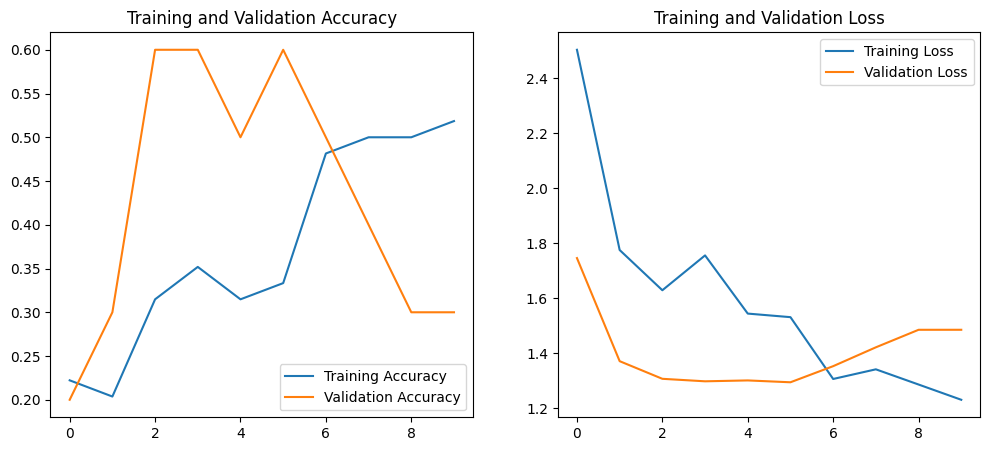

Performance metrics plotted.


In [ ]:
# =====================================================================
# 5. VISUALIZATION OF PERFORMANCE
# =====================================================================
def plot_metrics(history):
    acc = history.history['accuracy']
    val_acc = history.history['val_accuracy']
    loss = history.history['loss']
    val_loss = history.history['val_loss']
    epochs_range = range(len(acc))

    plt.figure(figsize=(12, 5))

    plt.subplot(1, 2, 1)
    plt.plot(epochs_range, acc, label='Training Accuracy')
    plt.plot(epochs_range, val_acc, label='Validation Accuracy')
    plt.legend(loc='lower right')
    plt.title('Training and Validation Accuracy')

    plt.subplot(1, 2, 2)
    plt.plot(epochs_range, loss, label='Training Loss')
    plt.plot(epochs_range, val_loss, label='Validation Loss')
    plt.legend(loc='upper right')
    plt.title('Training and Validation Loss')
    plt.show()

plot_metrics(history)

print("Performance metrics plotted.")

In [ ]:
# =====================================================================
# 6. EVALUATION METRICS
# =====================================================================
print("\n--- Running Evaluation Metrics ---")
# Reset validation generator to ensure order is preserved
val_generator.reset()

# Get model predictions
predictions = model.predict(val_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = val_generator.classes
class_labels = list(val_generator.class_indices.keys())

# Get unique labels present in y_true to pass to classification_report
unique_y_true_labels = np.unique(y_true)
# Map these unique numeric labels back to their string names
# This assumes class_labels is ordered by the class indices (0, 1, 2, ...)
actual_target_names = [class_labels[i] for i in unique_y_true_labels]

# Confusion Matrix
cm = confusion_matrix(y_true, y_pred)
print("Confusion Matrix:")
print(cm)

# Comprehensive Report (Precision, Recall, F1-score)
print("\nClassification Report:")
print(classification_report(y_true, y_pred, target_names=actual_target_names, labels=unique_y_true_labels))

print("Evaluation metrics generated.")


--- Running Evaluation Metrics ---
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step
Confusion Matrix:
[[1 1 0 0]
 [0 2 0 0]
 [2 0 0 0]
 [0 0 1 3]]

Classification Report:
                precision    recall  f1-score   support

 1 rupee coins       0.33      0.50      0.40         2
10 rupee coins       0.67      1.00      0.80         2
 2 rupee coins       0.00      0.00      0.00         2
 5 rupee coins       1.00      0.75      0.86         4

      accuracy                           0.60        10
     macro avg       0.50      0.56      0.51        10
  weighted avg       0.60      0.60      0.58        10

Evaluation metrics generated.


## 8. Misclassified Images Visualization

To understand where the model is struggling, let's visualize some of the images that were misclassified in the validation set. This can provide insights into visual similarities between classes or problematic image characteristics.

Found 4 misclassified images.


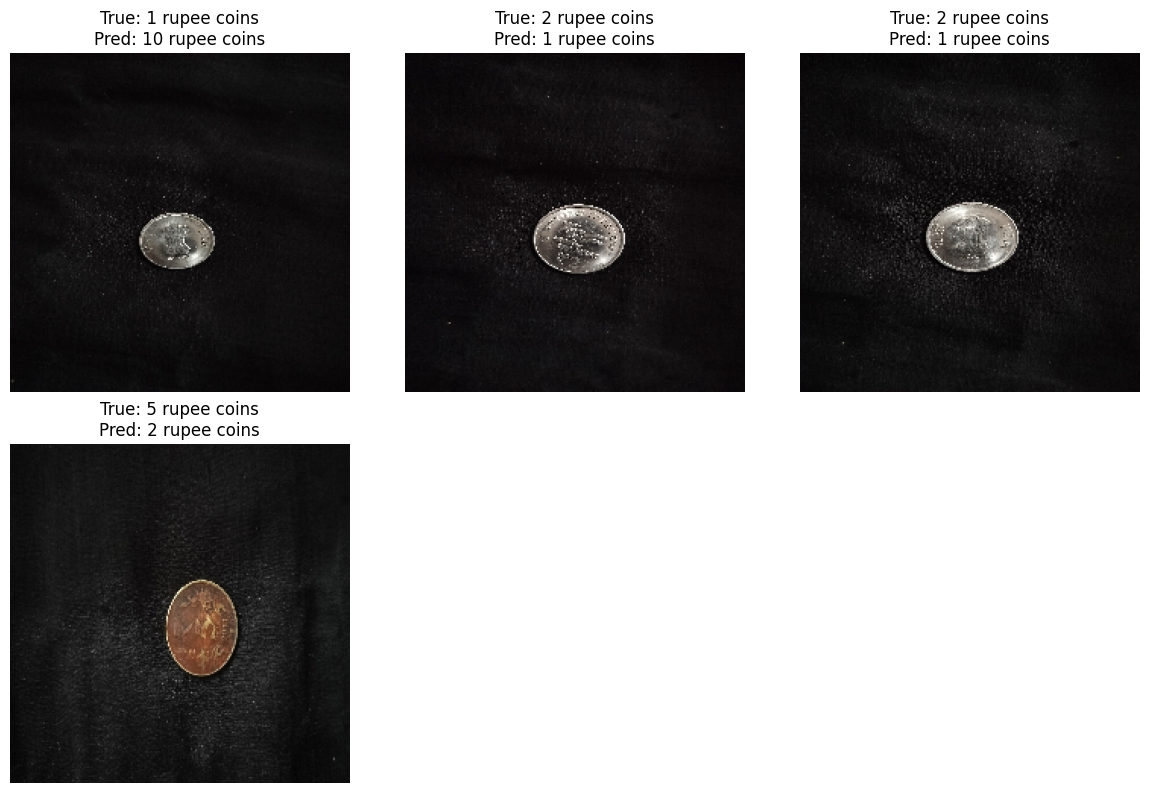

Misclassified images visualization complete.


In [ ]:
import math
import matplotlib.pyplot as plt

# Re-obtain class labels from the generator
class_labels = list(train_generator.class_indices.keys())

# Identify misclassified samples
misclassified_indices = np.where(y_true != y_pred)[0]

print(f"Found {len(misclassified_indices)} misclassified images.")

if len(misclassified_indices) > 0:
    # Reset validation generator and get all images and true labels in order.
    # Since BATCH_SIZE (32) > total_val_images (10), there's typically only one batch.
    # We need to ensure the generator is reset to get images in the same order as y_true/y_pred.
    val_generator.reset()
    all_val_images, _ = val_generator[0] # Get the first (and likely only) batch of images

    # Extract misclassified images and their true/predicted labels
    misclassified_images = all_val_images[misclassified_indices]
    misclassified_true_labels = [class_labels[label] for label in y_true[misclassified_indices]]
    misclassified_predicted_labels = [class_labels[label] for label in y_pred[misclassified_indices]]

    # Plot misclassified images
    num_misclassified = len(misclassified_images)
    rows = int(math.ceil(num_misclassified / 3.0)) # Display max 3 images per row
    cols = min(num_misclassified, 3) # At most 3 columns

    plt.figure(figsize=(cols * 4, rows * 4)) # Adjust figure size dynamically

    for i in range(num_misclassified):
        plt.subplot(rows, cols, i + 1)
        plt.imshow(misclassified_images[i])
        plt.title(f"True: {misclassified_true_labels[i]}\nPred: {misclassified_predicted_labels[i]}")
        plt.axis('off')
    plt.tight_layout()
    plt.show()
else:
    print("No misclassified images to display.")

print("Misclassified images visualization complete.")

## 7. Prediction on a New Image

Now, let's use our trained model to predict the class of a new, unseen coin image. This involves loading the image, preprocessing it to match the input requirements of our model (resizing and normalization), and then running the prediction.

Attempting to find an alternative image within the dataset for demonstration purposes...
Found alternative image: '/content/drive/MyDrive/Dataset-clg/5 rupee coins/IMG20260610203447.jpg'
New image loaded and preprocessed: /content/drive/MyDrive/Dataset-clg/5 rupee coins/IMG20260610203447.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step


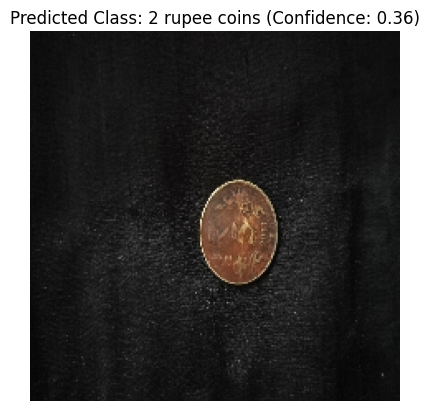

The model predicts the coin is: 2 rupee coins
Prediction probabilities: [0.14942296 0.12309318 0.36455384 0.12919764 0.23373228]


In [ ]:
from tensorflow.keras.preprocessing import image
import numpy as np
import matplotlib.pyplot as plt
import os

# Path to your new image. REMEMBER TO CHANGE THIS TO YOUR IMAGE PATH.
new_image_path = '/content/drive/MyDrive/Dataset-clg/5 rupee coins/IMG_20230206_164803.jpg'

# --- Logic to handle FileNotFoundError and find an alternative image ---
if not os.path.exists(new_image_path):
    print(f"Warning: The specified image path '{new_image_path}' was not found.")
    print("Attempting to find an alternative image within the dataset for demonstration purposes...")

    found_alternative = False
    for root, _, files in os.walk(DATA_DIR):
        for file in files:
            if file.lower().endswith(('.png', '.jpg', '.jpeg', '.gif', '.bmp')):
                # Found the first image in the dataset
                new_image_path = os.path.join(root, file)
                found_alternative = True
                print(f"Found alternative image: '{new_image_path}'")
                break
        if found_alternative:
            break

    if not found_alternative:
        raise FileNotFoundError("Error: Could not find any image in the dataset directory for prediction. Please update 'new_image_path' to a valid image file path within your mounted Google Drive dataset.")
# --- End new logic ---

# Load the image
img = image.load_img(new_image_path, target_size=IMG_SIZE)
img_array = image.img_to_array(img)
img_array = np.expand_dims(img_array, axis=0)  # Create a batch dimension

# Normalize the image (same as during training)
img_array = img_array / 255.0

print(f"New image loaded and preprocessed: {new_image_path}")

# Make a prediction
predictions = model.predict(img_array)
predicted_class_index = np.argmax(predictions[0])
# train_generator.class_indices is an ordered dictionary, we need to get keys by index
predicted_class_name = list(train_generator.class_indices.keys())[predicted_class_index]

# Display the image and prediction
plt.imshow(img)
plt.title(f"Predicted Class: {predicted_class_name} (Confidence: {np.max(predictions[0]):.2f})")
plt.axis('off')
plt.show()

print(f"The model predicts the coin is: {predicted_class_name}")
print(f"Prediction probabilities: {predictions[0]}")